In [13]:
import pandas as pd
import numpy as np


In [14]:
df = pd.read_csv("../data/MaternalDS.csv", encoding="utf-8-sig")

In [15]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [16]:
df.isna().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [17]:
df.sample(10)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
541,49,120,90,7.5,98.0,77,low risk
289,50,120,80,7.7,98.0,70,low risk
664,21,90,50,6.9,98.0,60,low risk
717,13,90,65,7.9,101.0,80,mid risk
1004,13,90,65,9.0,101.0,80,high risk
544,20,100,90,7.5,98.0,88,low risk
425,35,100,60,15.0,98.0,80,high risk
77,55,120,90,12.0,98.0,70,mid risk
758,55,120,90,12.0,98.0,70,mid risk
331,44,120,90,16.0,98.0,80,mid risk


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [20]:
df.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

In [22]:
X = df.drop('RiskLevel', axis=1)

In [23]:
y = df['RiskLevel']

In [25]:
y

0       high risk
1       high risk
2       high risk
3       high risk
4        low risk
          ...    
1009    high risk
1010    high risk
1011    high risk
1012    high risk
1013     mid risk
Name: RiskLevel, Length: 1014, dtype: object

In [26]:
y.isna().sum()

0

In [29]:
from sklearn.preprocessing import LabelEncoder

In [30]:
le = LabelEncoder()

In [31]:
y = le.fit_transform(y)

In [32]:
y

array([0, 0, 0, ..., 0, 0, 2])

In [33]:
from sklearn.model_selection import train_test_split


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.25,
    random_state=42
)

In [35]:
from sklearn.pipeline import Pipeline

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
from sklearn.linear_model import LogisticRegression

In [41]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('riskModel', LogisticRegression(max_iter=1000))
    ])

In [ ]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('riskModel', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [44]:
from sklearn.metrics import classification_report, r2_score, accuracy_score

In [45]:
y_pred = pipeline.predict(X_test)

In [47]:
accuracy_score(y_test, y_pred)

0.6496062992125984

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.82      0.74        57
           1       0.64      0.87      0.74       102
           2       0.66      0.31      0.42        95

    accuracy                           0.65       254
   macro avg       0.66      0.67      0.63       254
weighted avg       0.65      0.65      0.62       254



In [51]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf = RandomForestClassifier(
    n_estimators = 200,
    criterion='entropy',
    random_state=42
)

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
param_grid = {
    'n_estimators' : [50, 100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
}

In [62]:
grid = GridSearchCV(
    rf,
    param_grid,
    cv = 10,
    scoring='accuracy',
    n_jobs=-1
)

In [63]:
grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [65]:
print(grid.best_estimator_)

RandomForestClassifier(criterion='entropy', max_depth=20, n_estimators=300,
                       random_state=42)


In [66]:
best_rv_model = grid.best_estimator_

In [68]:
y_pred_rv = best_rv_model.predict(X_test)

In [69]:
accuracy_score(y_test, y_pred_rv)

0.7992125984251969

In [70]:
print(classification_report(y_test, y_pred_rv))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87        57
           1       0.83      0.74      0.78       102
           2       0.74      0.81      0.77        95

    accuracy                           0.80       254
   macro avg       0.81      0.81      0.81       254
weighted avg       0.80      0.80      0.80       254



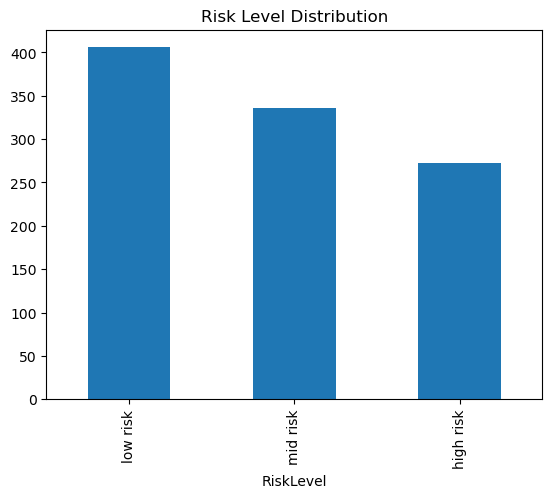

In [71]:
import matplotlib.pyplot as plt

df["RiskLevel"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()

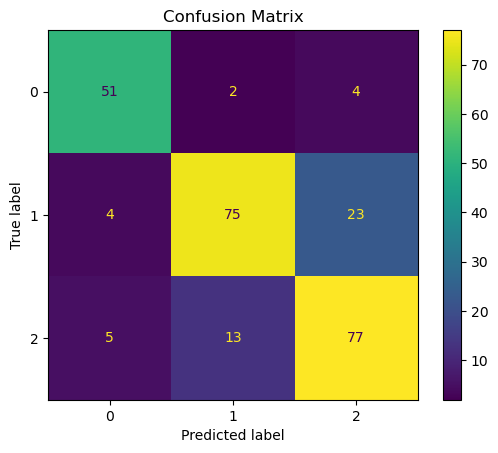

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rv)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [73]:
from sklearn.metrics import recall_score

recall_high = recall_score(y_test, y_pred_rv, pos_label=0, average=None)

/home/hosurvijay/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1784: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got None). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [75]:
from sklearn.metrics import roc_auc_score

probs = best_rv_model.predict_proba(X_test)

roc_score = roc_auc_score(y_test, probs, multi_class="ovr")
print("ROC-AUC:", roc_score)

ROC-AUC: 0.9302942685020917


In [76]:
print(X.columns)

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate'], dtype='object')


In [77]:
sample = [[25, 130, 80, 15.0, 98.0, 86]]

In [79]:
prediction = best_rv_model.predict(sample)
print("Encoded Prediction:", prediction)

Encoded Prediction: [0]


/home/hosurvijay/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [80]:
label = le.inverse_transform(prediction)
print("Predicted Risk Level:", label[0])

Predicted Risk Level: high risk


In [82]:
probs = best_rv_model.predict_proba(sample)
print("Class Probabilities:", probs)

Class Probabilities: [[0.88614815 0.01055556 0.1032963 ]]


/home/hosurvijay/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [83]:
print(le.classes_)

['high risk' 'low risk' 'mid risk']
